In [2]:
#importing all lbraries
import tensorflow as tf
from tensorflow import keras
from keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,Dropout

In [4]:
from tensorflow.keras import backend as k

In [5]:
#number of class dont change tunless the data changes

In [6]:
num_classes = 10

In [7]:
#size of batch and epochs
batch_size=64
epochs=24

In [14]:
#input image dinmension here we use for making 4d image becz in cnn models excepts 4d image -1 X img_rows X img_cols X 1 #not for resizeing becz input image is also on 28 X 28
img_rows,img_cols = 28,28

In [9]:
#the data ,shuffled and split between train and test set
(x_train,y_train),(x_test,y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 18s 2us/step


In [10]:
x_train.shape

(60000, 28, 28)

In [11]:
x_test.shape

(10000, 28, 28)

In [12]:
y_train.shape

(60000,)

In [15]:
#reshape my data
x_train = x_train.reshape(x_train.shape[0],img_rows,img_cols,1)
x_test = x_test.reshape(x_test.shape[0],img_rows,img_cols,1)

In [16]:
#defing input shape
input_shape = (img_rows,img_cols,1)

In [17]:
input_shape

(28, 28, 1)

In [18]:
x_train.shape

(60000, 28, 28, 1)

In [19]:
#feature scaling 
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')
x_train = x_train/255.
x_test = x_test/255.
print('x_train shape:',x_train)
print('x_test shape:',x_test)
print(y_train[0:3])

x_train shape: [[[[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  ...

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]]


 [[[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  ...

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]]


 [[[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  ...

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
 

In [20]:
# Convert labels'class vectors to binary class metrics  like onehotencodeing.....#enhanciing the labels for improving the tartget of prediction
y_train = tf.keras.utils.to_categorical(y_train,num_classes=num_classes)
y_test = tf.keras.utils.to_categorical(y_test,num_classes=num_classes)

In [25]:
#cnn code begins 
model = Sequential()
model.add(Conv2D(filters=32,kernel_size=(3,3),activation='relu',input_shape=input_shape))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Conv2D(filters=32,kernel_size=(3,3),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(units = 128,activation='relu'))
model.add(Dense(units = 64,activation='relu'))
model.add(Dense(units=num_classes,activation='softmax'))

C:\Users\ddeba\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [32]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)                    │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 11, 11, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 5, 5, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 800)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 128)                 │         102,528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 363,008 (1.38 MB)

 Trainable params: 121,002 (472.66 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 242,006 (945.34 KB)

In [26]:
model.compile(loss=keras.losses.categorical_crossentropy,optimizer=keras.optimizers.Adam(),metrics=['accuracy'])

In [27]:
hist = model.fit(x_train,y_train,batch_size=batch_size,epochs=epochs,verbose=1,validation_data=(x_test,y_test))

Epoch 1/24
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.9399 - loss: 0.1934 - val_accuracy: 0.9789 - val_loss: 0.0629
Epoch 2/24
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9829 - loss: 0.0563 - val_accuracy: 0.9820 - val_loss: 0.0587
Epoch 3/24
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9880 - loss: 0.0393 - val_accuracy: 0.9847 - val_loss: 0.0489
Epoch 4/24
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9906 - loss: 0.0299 - val_accuracy: 0.9894 - val_loss: 0.0291
Epoch 5/24
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9927 - loss: 0.0236 - val_accuracy: 0.9890 - val_loss: 0.0336
Epoch 6/24
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9933 - loss: 0.0201 - val_accuracy: 0.9901 - val_loss: 0.0301
Epoch 7/24
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9949 - loss: 0.0159 - val_accuracy: 0.9916 - val_loss: 0.0286
Epoch 8/24
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9956 - loss: 0.0129 - val_accuracy: 0.

In [30]:
hist.history

{'accuracy': [0.9398666620254517,
  0.9828833341598511,
  0.9879500269889832,
  0.9906499981880188,
  0.9927166700363159,
  0.993316650390625,
  0.9948999881744385,
  0.9955666661262512,
  0.9961333274841309,
  0.9965999722480774,
  0.9974833130836487,
  0.9975333213806152,
  0.9977666735649109,
  0.9975666403770447,
  0.9980833530426025,
  0.998033344745636,
  0.9983999729156494,
  0.9980166554450989,
  0.99836665391922,
  0.9984166622161865,
  0.9985166788101196,
  0.9986166954040527,
  0.9991333484649658,
  0.998533308506012],
 'loss': [0.19339832663536072,
  0.056276608258485794,
  0.03928784653544426,
  0.029911067336797714,
  0.023559777066111565,
  0.020136399194598198,
  0.015894794836640358,
  0.012939914129674435,
  0.011679491028189659,
  0.01043849065899849,
  0.008214721456170082,
  0.007627984043210745,
  0.007236998062580824,
  0.006653140299022198,
  0.005775259342044592,
  0.0056839375756680965,
  0.004695802927017212,
  0.005636483430862427,
  0.004725963808596134,
  

In [33]:
#evaluate the models with test data to get the scoree of "real data"
score = model.evaluate(x_test,y_test,verbose=0)
print('Test Loss:',score[0])
print('Test Accuracy:',score[1])

Test Loss: 0.06385079026222229
Test Accuracy: 0.9886999726295471


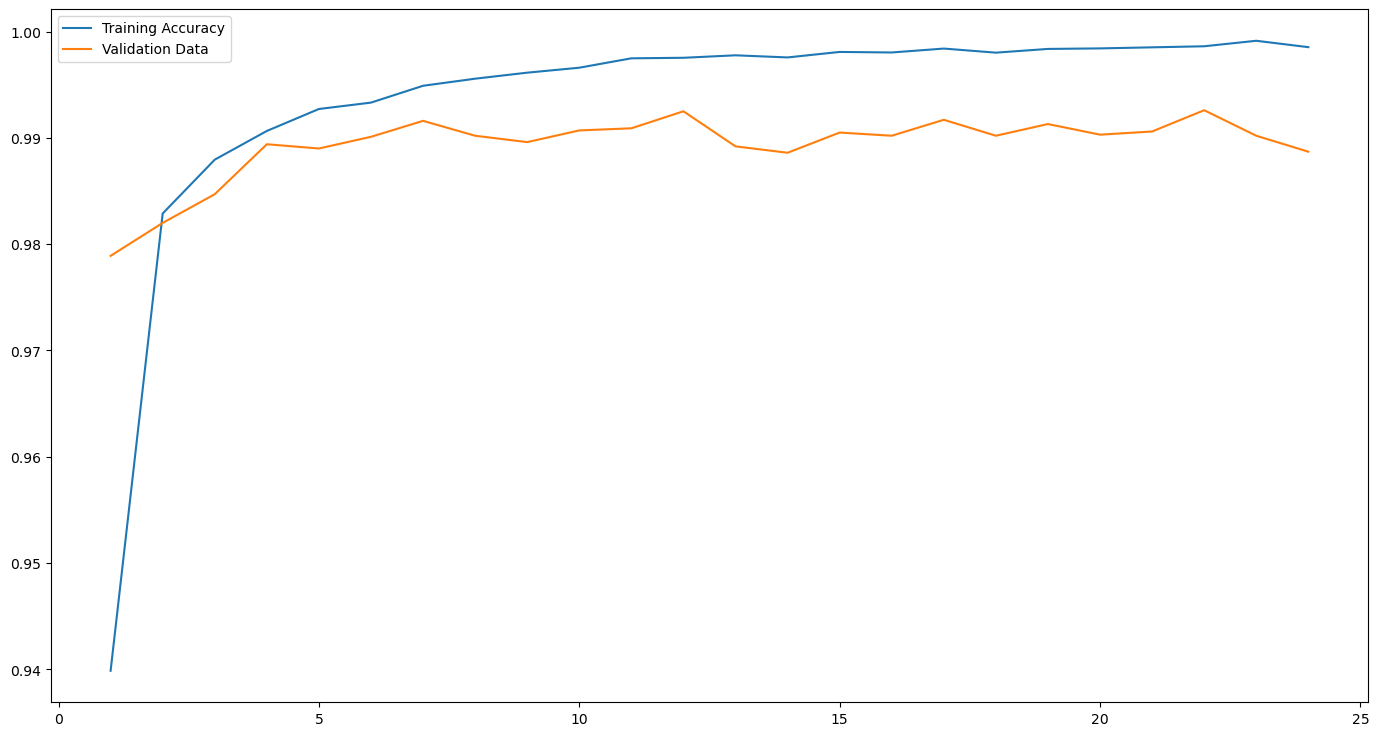

In [36]:
#plot data to see relationships in training and validation data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
plt.figure(figsize=(17,9))
epochs_list = list(range(1,len(hist.history['accuracy'])+1))
plt.plot(epochs_list,hist.history['accuracy'],epochs_list,hist.history['val_accuracy'])
plt.legend(['Training Accuracy','Validation Data'])
plt.show()